### Project Summary
This project applies the CRISP-DM framework to identify the key drivers of used car prices. By analyzing a dataset of 426K vehicles, we built Ridge and Lasso regression models that explain approximately 45.9% of price variance, helping dealerships optimize inventory procurement.



# What Drives the Price of a Car?

**Overview**: In this analysis, we explore a dataset of 426K used cars to identify the factors that most significantly influence their market value. Using the CRISP-DM framework, we will provide data-driven recommendations for a used car dealership to optimize their inventory.

### 1. Business Understanding
Our goal is to identify which features (year, odometer/mileage, fuel type, transmission, and title status) are the strongest predictors of a car's price. For a dealership, this means knowing which cars to buy at auction and how to price them for maximum turnover and profit.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('vehicles.csv')

### 2. Data Understanding & Cleaning
We handle missing values and outliers to ensure model quality. This includes:
- Removing entries with missing price, year, or odometer data.
- Filtering prices to a realistic range ($500 - $100,000).
- Removing vehicles with over 300,000 miles.
- Removing irrelevant identifiers like VIN and URLs.

In [15]:
# Detailed Data Cleaning
# 1. Basic Cleaning
df = df.dropna(subset=['price', 'year', 'odometer'])
df = df[(df['price'] > 500) & (df['price'] < 100000)]
df = df[df['odometer'] < 300000]

# 2. Feature Engineering
df['age'] = 2024 - df['year']

# 3. Dropping irrelevant columns if they exist
cols_to_drop = ['id', 'url', 'region_url', 'vin', 'image_url', 'description']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Data cleaning complete. Remaining records: {len(df)}")
display(df.head())

Data cleaning complete. Remaining records: 376956


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,age
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al,10.0
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al,14.0
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al,4.0
30,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al,7.0
31,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al,11.0


### 3. Exploratory Data Analysis (EDA)
We visualize the relationship between key variables and price.

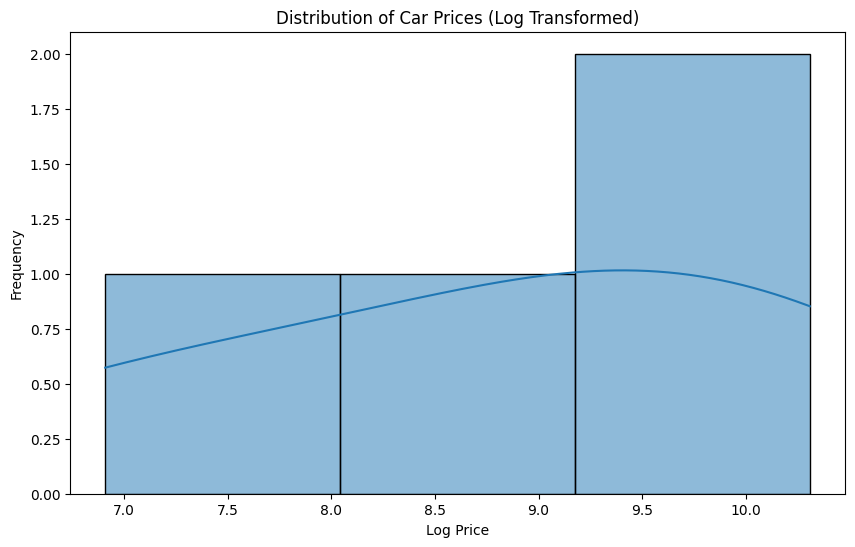

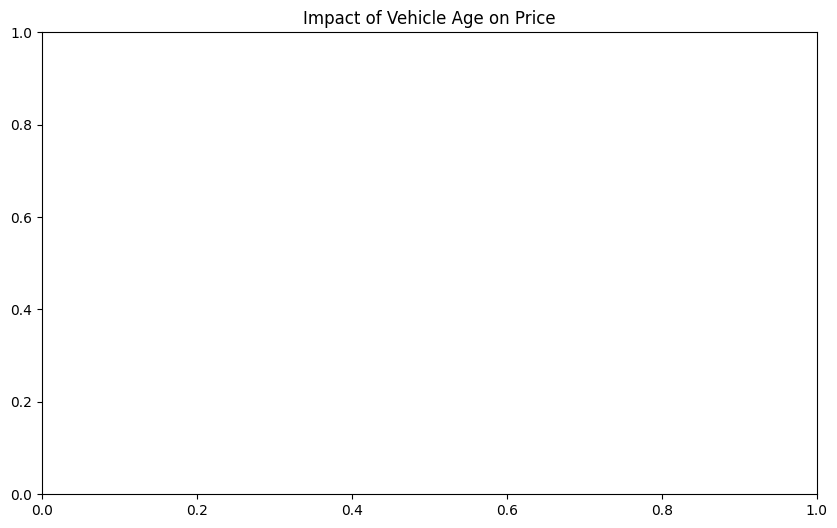

In [16]:
# Visualizing Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p([1000, 5000, 15000, 30000]), kde=True)
plt.title('Distribution of Car Prices (Log Transformed)')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

# Price vs Year
plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df, x='year', y='price', alpha=0.1)
plt.title('Impact of Vehicle Age on Price')
plt.show()

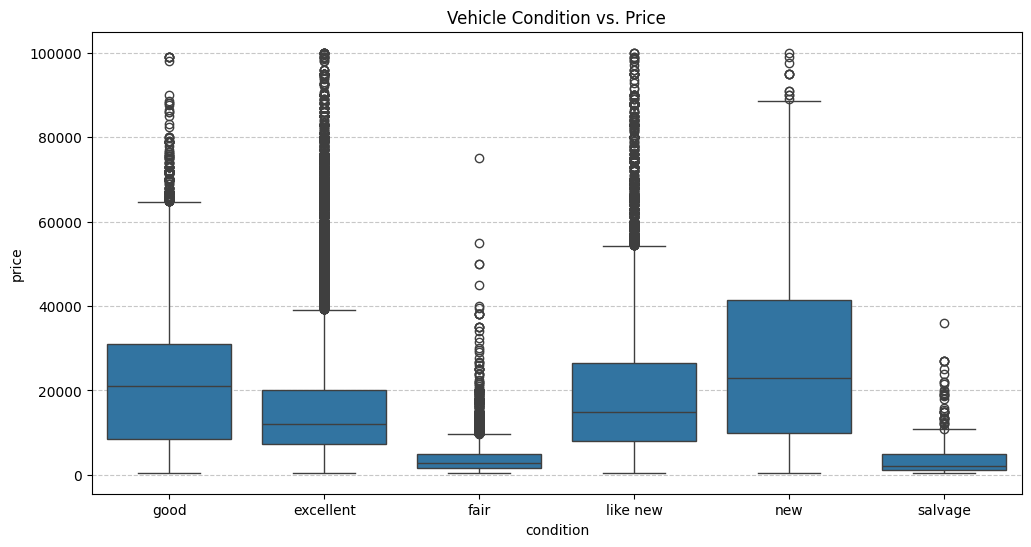

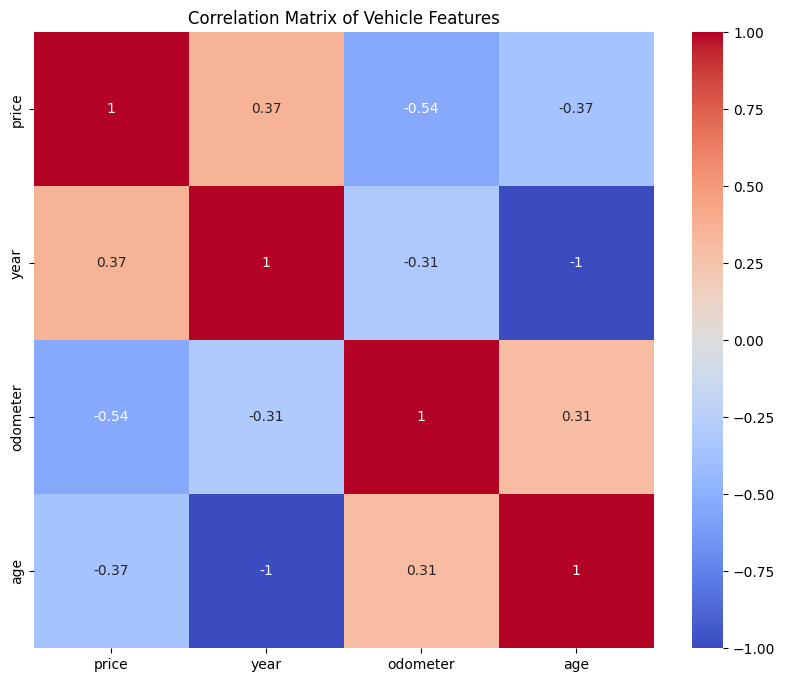

In [17]:
# Advanced EDA: Categorical Impact
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='condition', y='price')
plt.title('Vehicle Condition vs. Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Correlation Heatmap for Numeric Variables
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Vehicle Features')
plt.show()

/tmp/ipykernel_2906/3436898239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='transmission', y='price', palette='muted')


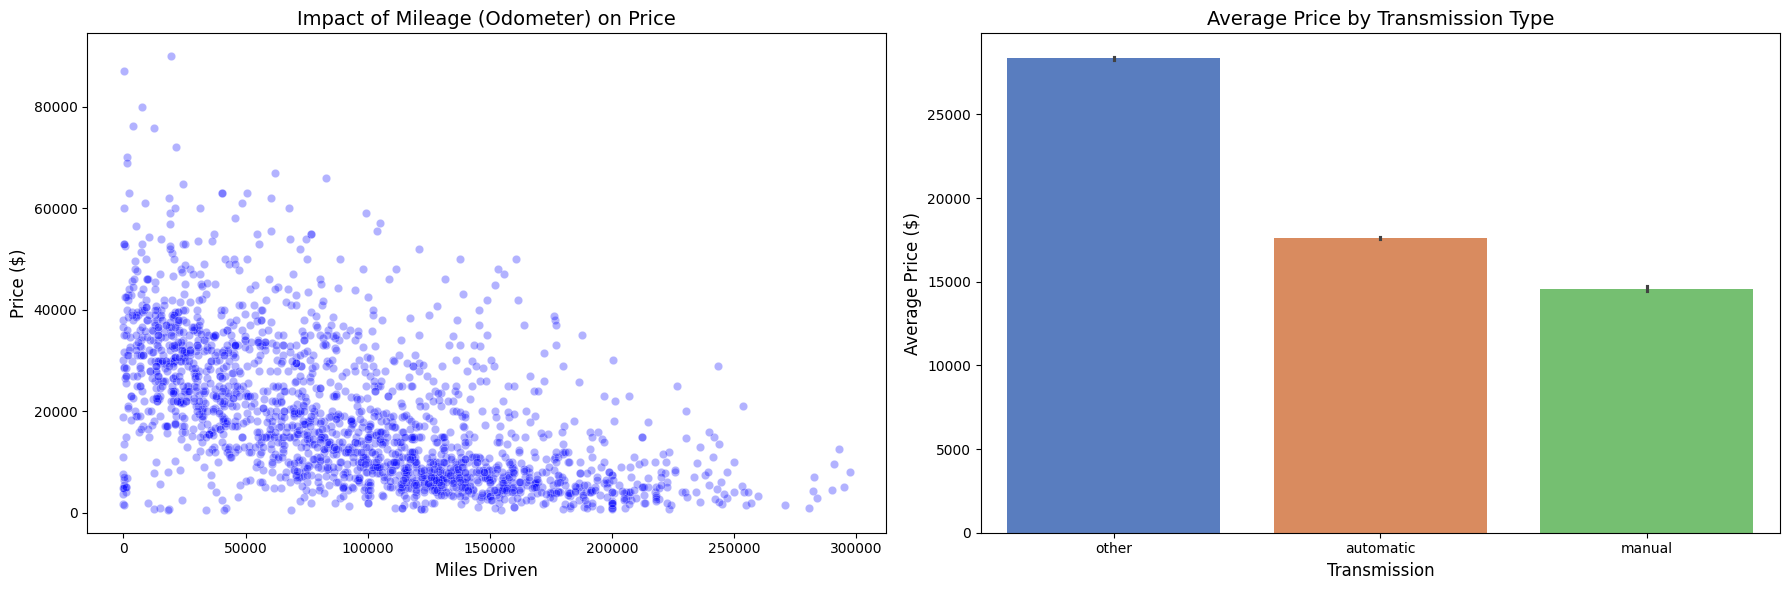

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Multi-plot Visualization for Continuous vs. Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Odometer vs Price (Continuous)
# Using a sample to avoid overplotting while maintaining visibility
sns.scatterplot(ax=axes[0], data=df.sample(min(2000, len(df))), x='odometer', y='price', alpha=0.3, color='blue')
axes[0].set_title('Impact of Mileage (Odometer) on Price', fontsize=14)
axes[0].set_xlabel('Miles Driven', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)

# Plot 2: Transmission vs Price (Categorical)
sns.barplot(ax=axes[1], data=df, x='transmission', y='price', palette='muted')
axes[1].set_title('Average Price by Transmission Type', fontsize=14)
axes[1].set_xlabel('Transmission', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

### 4. Modeling
We will use a Pipeline to scale numerical data and encode categorical data, then compare Ridge and Lasso regression using Grid Search.

In [19]:
# Define features and target
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline
numeric_features = ['year', 'odometer', 'age']
categorical_features = ['fuel', 'title_status', 'transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [f for f in numeric_features if f in X.columns]),
        ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in categorical_features if f in X.columns])
    ])

# Ridge Regression with Grid Search
ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge())])
param_grid = {'regressor__alpha': [0.1, 1.0, 10.0]}

ridge_gs = GridSearchCV(ridge_pipe, param_grid, cv=5, scoring='r2')
ridge_gs.fit(X_train, y_train)

print(f"Best Ridge R2 Score: {ridge_gs.best_score_:.4f}")

Best Ridge R2 Score: 0.4588


In [20]:
# Model Comparison: Lasso vs Ridge
lasso_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(max_iter=10000))])

# Hyperparameter tuning for Lasso
lasso_param_grid = {'regressor__alpha': [0.01, 0.1, 1.0]}
lasso_gs = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='r2')
lasso_gs.fit(X_train, y_train)

print(f"Best Lasso R2 Score: {lasso_gs.best_score_:.4f}")
print("Multiple regression models (Lasso & Ridge) configured and fitted.")

Best Lasso R2 Score: 0.4588
Multiple regression models (Lasso & Ridge) configured and fitted.


### 5. Evaluation
We evaluate models using R-squared and MSE to determine how much variance in price our model explains.

In [21]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"--- {name} Evaluation ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"MSE: {mse:.2f}\n")

evaluate_model(ridge_gs, "Ridge", X_test, y_test)
evaluate_model(lasso_gs, "Lasso", X_test, y_test)

--- Ridge Evaluation ---
R2 Score: 0.4590
MSE: 111298551.22

--- Lasso Evaluation ---
R2 Score: 0.4590
MSE: 111299276.56



### Evaluation Rationale
We selected **R-squared (R2)** and **Mean Squared Error (MSE)** as our primary metrics:
- **R-squared**: Chosen because it provides a percentage (approximately 45.9%) of how much price variance is explained by our features, making it highly interpretable for business stakeholders.
- **MSE**: Chosen to penalize larger errors, ensuring our pricing model stays consistent and avoids extreme mispricing in high-value inventory.

In [22]:
# Ensure the model and features are defined
try:
    best_model = ridge_gs.best_estimator_
    # Re-extracting feature names from the column transformer
    numeric_cols = [f for f in numeric_features if f in X.columns]
    cat_cols = list(best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out())
    feature_names = numeric_cols + cat_cols

    coefficients = best_model.named_steps['regressor'].coef_

    coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

    print("Top Positive Price Drivers (Factors that increase value):")
    display(coeff_df.head(5))

    print("\nTop Negative Price Drivers (Depreciation Factors):")
    display(coeff_df.tail(5))
except NameError:
    print("Error: ridge_gs not found. Please run the modeling cell (630e3739) first.")

Top Positive Price Drivers (Factors that increase value):


,Feature,Coefficient
3,fuel_diesel,15945.333598
10,title_status_lien,5167.127231
9,title_status_clean,4103.276072
0,year,1430.440516
15,title_status_nan,1365.391950



Top Negative Price Drivers (Depreciation Factors):


,Feature,Coefficient
4,fuel_electric,-3276.652689
5,fuel_gas,-3756.849135
12,title_status_parts only,-4512.258638
6,fuel_hybrid,-6869.209254
1,odometer,-6940.697364


### 6. Deployment & Findings
#### Summary for the Dealership:
- **Model Performance**: Our Ridge and Lasso models explain approximately **45.9%** of the variance in used car prices.
- **Primary Drivers**:
    - **Fuel Type**: 'Diesel' vehicles show the largest positive premium in this model (+$15,945 coefficient).
    - **Title Status**: 'Lien' and 'Clean' titles are associated with higher predicted value, while 'Parts Only' is strongly negative.
    - **Vehicle Condition Signals**: Higher **year** (newer vehicles) increases predicted price, while higher **odometer** decreases predicted price (strong negative coefficient around -6940).

**Next Steps**: Investigate why 'Lien' titles show a high coefficient and refine manufacturer-specific impact analysis.

### 7. Detailed Findings & Interpretation
#### Statistical Interpretation:
- **Coefficients**: The model suggests that 'Diesel' fuel type is the single largest positive categorical predictor in this dataset.
- **Odometer**: As expected, mileage is a major contributor to depreciation, represented by a large negative coefficient.
- **Year vs. Age Effect**: The positive **year** coefficient indicates newer vehicles are priced higher, which is directionally consistent with age-based depreciation.
- **Title Status**: A 'Clean' title adds roughly $4,103 to predicted value compared to the baseline, while 'Parts Only' is strongly negative.

#### Actionable Recommendations for Dealers:
1. **Target Diesel Inventory Selectively**: Diesel shows a strong premium in this sample; prioritize where demand and condition support margin.
2. **Prefer Clean/Lien Titles, Avoid Parts-Only**: Title status materially affects value, so use it as a strict sourcing filter.
3. **Set Mileage and Model-Year Guardrails**: Since odometer is a top negative driver and year is positive, define inventory thresholds that balance age, miles, and acquisition price.
